In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [2]:
import os

base_path = '/kaggle/input'
dataset_folder = os.listdir(base_path)[0]
print("Dataset folder:", dataset_folder)

csv_path = os.path.join(base_path, dataset_folder, 'indexProcessed.csv')
print("CSV path:", csv_path)

df = pd.read_csv(csv_path)
print("Initial shape:", df.shape)

df.head()

Dataset folder: stock-exchange-data
CSV path: /kaggle/input/stock-exchange-data/indexProcessed.csv
Initial shape: (104224, 9)


,Index,Date,Open,High,Low,Close,Adj Close,Volume,CloseUSD
0,HSI,1986-12-31,2568.300049,2568.300049,2568.300049,2568.300049,2568.300049,0.0,333.879006
1,HSI,1987-01-02,2540.100098,2540.100098,2540.100098,2540.100098,2540.100098,0.0,330.213013
2,HSI,1987-01-05,2552.399902,2552.399902,2552.399902,2552.399902,2552.399902,0.0,331.811987
3,HSI,1987-01-06,2583.899902,2583.899902,2583.899902,2583.899902,2583.899902,0.0,335.906987
4,HSI,1987-01-07,2607.100098,2607.100098,2607.100098,2607.100098,2607.100098,0.0,338.923013


In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("After sorting:", df.shape)

After sorting: (104224, 9)


In [4]:
df['MA_5'] = df['Close'].rolling(5).mean()
df['MA_10'] = df['Close'].rolling(10).mean()

df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

df = df.dropna().copy()

print("After feature engineering:", df.shape)

After feature engineering: (104215, 12)


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


In [5]:
features = ['MA_5', 'MA_10', 'Volume']

X = df[features]
y = df['Target']

split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (83372, 3)
X_test shape: (20843, 3)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.76      0.65     10433
           1       0.63      0.41      0.50     10410

    accuracy                           0.59     20843
   macro avg       0.60      0.59      0.57     20843
weighted avg       0.60      0.59      0.57     20843



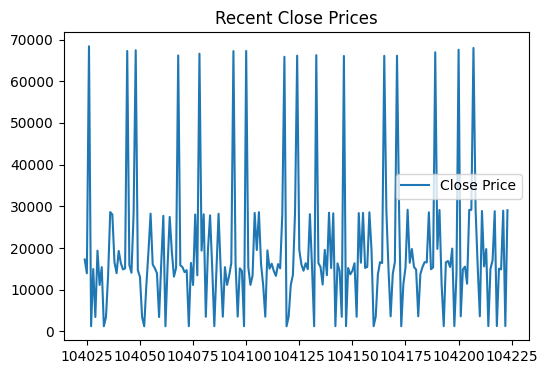

In [8]:
plt.figure(figsize=(6,4))
plt.plot(df['Close'][-200:], label='Close Price')
plt.legend()
plt.title("Recent Close Prices")
plt.show()